# Loan Approval Prediction — EDA & Feature Selection

In [4]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.feature_selection import get_correlation_with_target, find_highly_correlated_pairs, select_features
from src.utils import print_section

In [5]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [6]:
df = pd.read_csv("../data/loan_approval_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (4269, 16)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,asset_to_loan_ratio,cibil_band
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,50700000,3.114583,1.695652,Good
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,17000000,2.975610,1.393443,Poor
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,57700000,3.263736,1.942761,Poor
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,52700000,3.743902,1.716612,Poor
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,55000000,2.469388,2.272727,Poor


The cleaned dataset is loaded successfully.
It contains encoded categorical variables,
engineered features,
and scaled numerical values.

## 1. Univariate Analysis

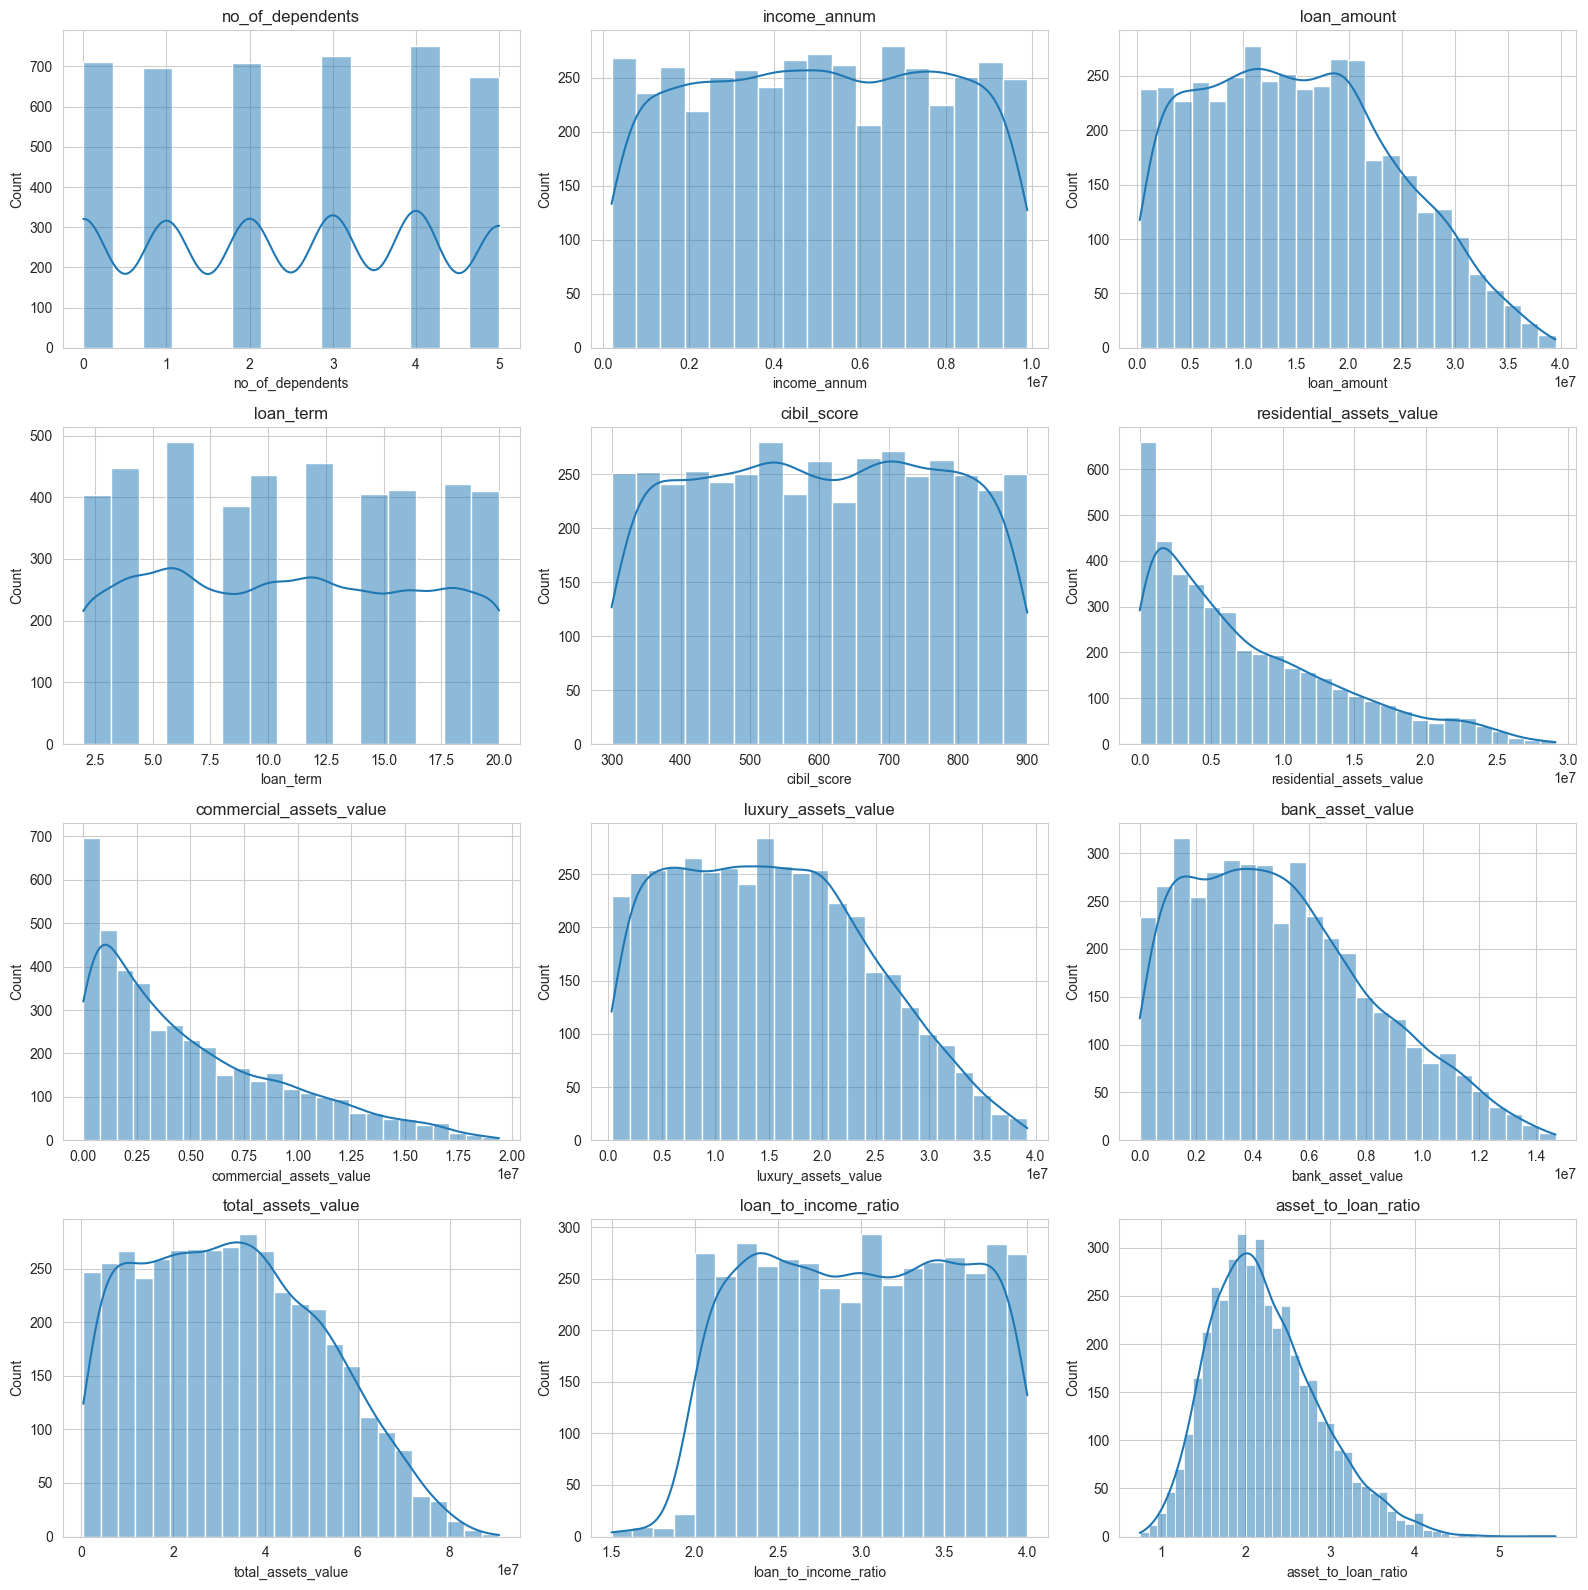

In [7]:
numeric_cols = df.select_dtypes(include="number").drop(columns=["education", "self_employed", "loan_status"], errors="ignore").columns

fig, axes = plt.subplots(nrows=(len(numeric_cols)+2)//3, ncols=3, figsize=(16, 4*((len(numeric_cols)+2)//3)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("../images/day3_univariate_histograms.png", dpi=100)
plt.show()


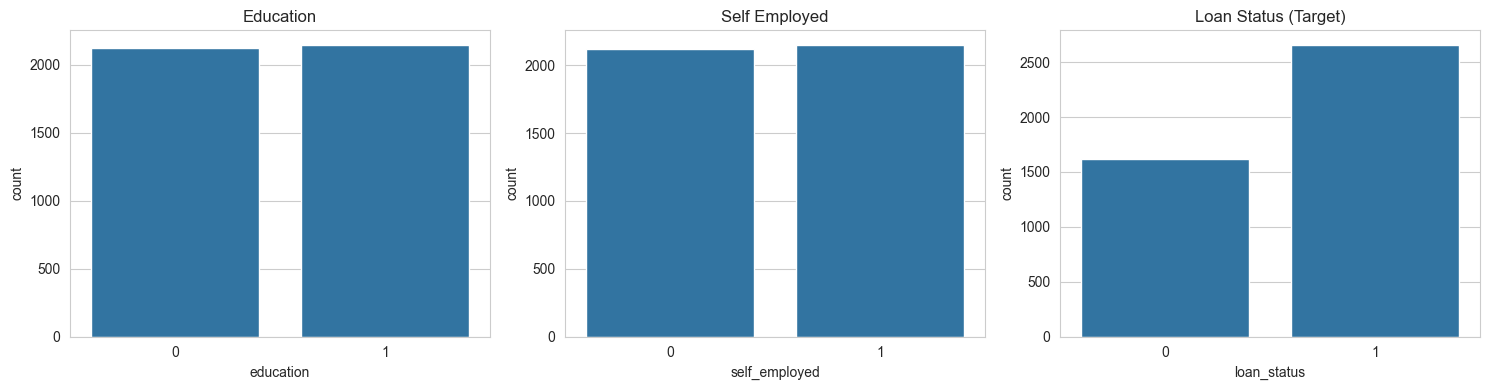

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="education", data=df, ax=axes[0])
axes[0].set_title("Education")
sns.countplot(x="self_employed", data=df, ax=axes[1])
axes[1].set_title("Self Employed")
sns.countplot(x="loan_status", data=df, ax=axes[2])
axes[2].set_title("Loan Status (Target)")
plt.tight_layout()
plt.savefig("../images/day3_univariate_categorical.png", dpi=100)
plt.show()


**Univariate observations:**

- Most financial variables are right-skewed (skew 0.3-0.98). Features such as income_annum, loan_amount, residential_assets_value, commercial_assets_value, luxury_assets_value, bank_asset_value, and total_assets_value contain a small number of very high values, which creates a longer right tail in their distributions. This pattern is common in income and asset-related data.

- CIBIL scores are distributed across a wide range of values. The distribution is fairly even, with only a very slight left skew (skew ≈ -0.01), indicating that applicants are not concentrated within a single credit score range.

- The categorical features are reasonably balanced. Both education and self_employed contain proportions that are close to a 50:50 split, which helps reduce bias caused by highly uneven category distributions.

- The target variable is moderately imbalanced. Approximately 62.2% of applications are Approved and 37.8% are Rejected. This imbalance should be considered during preprocessing and model evaluation to ensure reliable predictive performance.

## 2. Bivariate Analysis — Features vs. Target

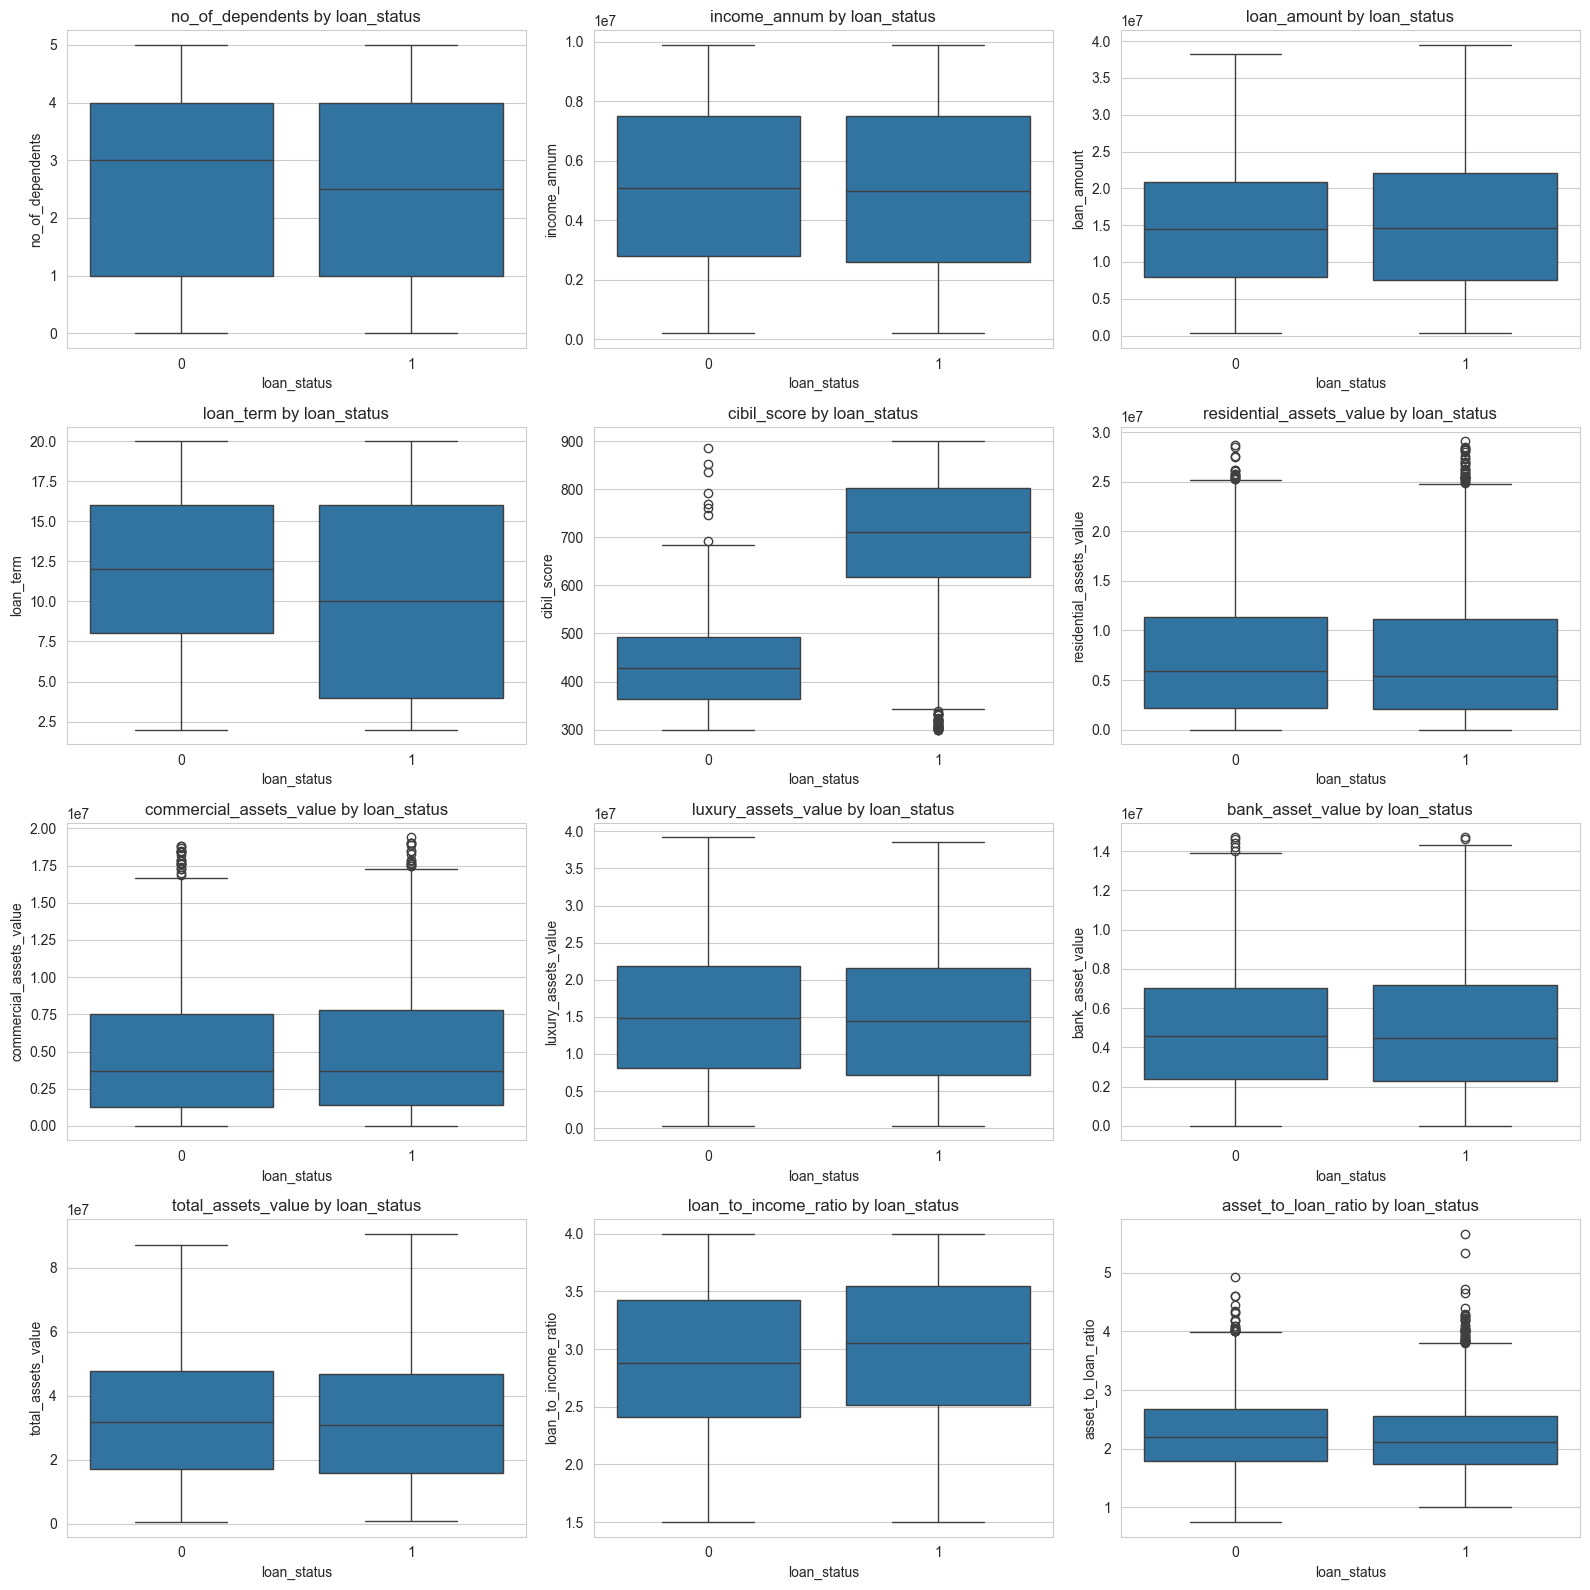

In [9]:
fig, axes = plt.subplots(nrows=(len(numeric_cols)+2)//3, ncols=3, figsize=(16, 4*((len(numeric_cols)+2)//3)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x="loan_status", y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} by loan_status")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("../images/day3_bivariate_boxplots.png", dpi=100)
plt.show()


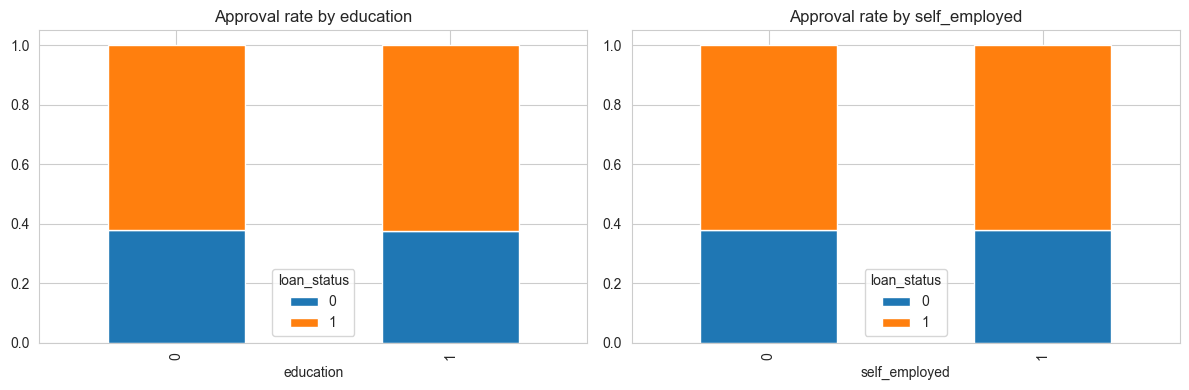

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.crosstab(df["education"], df["loan_status"], normalize="index").plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Approval rate by education")
pd.crosstab(df["self_employed"], df["loan_status"], normalize="index").plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Approval rate by self_employed")
plt.tight_layout()
plt.savefig("../images/day3_bivariate_categorical.png", dpi=100)
plt.show()


**Bivariate observations:**

- CIBIL score is the strongest indicator of loan approval. Applicants with approved loans have an average CIBIL score of 703, while rejected applicants have an average score of 429. This large difference suggests that credit score has a significant influence on the approval decision.

- Education level has very little impact on loan approval. The approval rate is 62.0% for Graduates and 62.5% for Non-Graduates, indicating that both groups are approved at almost the same rate.

- Self-employment status does not show a meaningful relationship with loan approval. Approval rates are 62.2% for self-employed applicants and 62.0% for non-self-employed applicants, which is nearly identical to the overall approval rate.

- Loan term and financial ratios show only a weak relationship with the target variable. Features such as loan_term, loan_to_income_ratio, and asset_to_loan_ratio display some variation between approved and rejected applicants, but the separation is relatively small compared to the CIBIL score.